### Загрузка данных

- Датасет содержит тексты на английском с метками эмоций (6 классов: anger, fear, joy, love, sadness, surprise).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/emotion_dataset.csv')

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'].values, df['emotion'].values, test_size=0.2, random_state=42, stratify=df['emotion']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f'train: {len(train_texts)}')
print(f'val: {len(val_texts)}')
print(f'test: {len(test_texts)}')
print(f'\nклассы: {set(train_labels)}')

train: 30555
val: 3819
test: 3820

классы: {'surprise', 'joy', 'sadness', 'anger', 'fear', 'love'}


### Токенизация и подготовка данных
- Токенизатор Keras с максимальным словарём 10000 слов, oov_token=`<unk>`.

- Максимальная длина последовательности - 100 токенов (обрезание и паддинг постфиксом).

- Целевые метки преобразуются через `LabelEncoder`.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

tokenizer = Tokenizer(num_words=20000, oov_token='<unk>')
tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq = tokenizer.texts_to_sequences(val_texts)
X_test_seq = tokenizer.texts_to_sequences(test_texts)

max_len=100
X_train = torch.tensor(pad_sequences(X_train_seq, padding='post', truncating='post', maxlen=max_len))
X_val = torch.tensor(pad_sequences(X_val_seq, padding='post', truncating='post', maxlen=max_len))
X_test = torch.tensor(pad_sequences(X_test_seq, padding='post', truncating='post', maxlen=max_len))

le = LabelEncoder()
y_train = torch.tensor(le.fit_transform(train_labels))
y_val = torch.tensor(le.transform(val_labels))
y_test = torch.tensor(le.transform(test_labels))

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16, shuffle=False)

print(f'классы: {le.classes_}')
print(f'размер словаря: {len(tokenizer.word_index)}')
print(f'train_loader: {len(train_loader)} батчей')
print(f'val_loader: {len(val_loader)} батчей')
print(f'test_loader: {len(test_loader)} батчей')

классы: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']
размер словаря: 20846
train_loader: 1910 батчей
val_loader: 239 батчей
test_loader: 239 батчей


In [ ]:
num_classes = len(le.classes_)
print(f'количество классов: {num_classes}')
print(f'классы: {le.classes_}')

количество классов: 6
классы: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


### Архитектуры моделей
- **LSTM**: двунаправленный LSTM (2 слоя) + средний пулинг + BatchNorm + Dropout (0.3) -> 6 классов.
- **Transformer**: Embedding + PositionalEncoding + один слой TransformerEncoder + маскирование паддингов + max pooling -> 6 классов.

In [ ]:
from torch.nn import Embedding, LSTM, Module, Dropout, Linear, ReLU,TransformerEncoderLayer, TransformerEncoder, BatchNorm1d
from torch import optim
import math

class LSTMModel(Module):
  def __init__(self, vocab_size, embed_size=128, hidden_size=128, num_classes=6):
    super().__init__()
    self.embedding=Embedding(vocab_size, embed_size)
    self.lstm=LSTM(embed_size, hidden_size, batch_first=True, bidirectional=True, num_layers=2)
    self.batchnorm =BatchNorm1d(hidden_size*2)
    self.dropout=Dropout(0.3)
    self.fc1=Linear(hidden_size*2, hidden_size)
    self.fc2=Linear(hidden_size, num_classes)
    self.relu=ReLU()

  def forward(self, x):
    x=self.embedding(x)
    output, (_,_)=self.lstm(x)
    x=torch.mean(output, dim=1)
    x=self.batchnorm(x)
    x=self.dropout(x)
    x=self.relu(self.fc1(x))
    x=self.dropout(x)
    x=self.fc2(x)
    return x



class PositionalEncoding(Module):
  def __init__(self, d_model, max_len=5000):
    super().__init__()
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    return x + self.pe[:, :x.size(1), :]


class TransformerModel(Module):
  def __init__(self, vocab_size, embed_size=128, hidden_size=128, num_classes=6, max_len=200):
    super().__init__()
    self.embedding = Embedding(vocab_size, embed_size, padding_idx=0)
    self.pos_encoder = PositionalEncoding(embed_size, max_len)
    encoder_layer = TransformerEncoderLayer(d_model=embed_size, nhead=4,
                                            dim_feedforward=hidden_size,
                                            dropout=0.3, batch_first=True)
    self.transformer = TransformerEncoder(encoder_layer, num_layers=2)
    self.batchnorm = BatchNorm1d(embed_size)
    self.dropout = Dropout(0.5)
    self.fc1 = Linear(embed_size, hidden_size)
    self.fc2 = Linear(hidden_size, num_classes)
    self.relu = ReLU()

  def forward(self, x):
    mask = (x==0)
    x=self.embedding(x)
    x=self.pos_encoder(x)
    x=self.transformer(x, src_key_padding_mask=mask)
    x=torch.mean(x, dim=1)
    x=self.batchnorm(x)
    x=self.dropout(x)
    x=self.relu(self.fc1(x))
    x=self.dropout(x)
    x=self.fc2(x)
    return x

### Функция обучения
- Оптимизатор Adam (weight_decay=1e-4)
- Scheduler ReduceLROnPlateau (patience=3, factor=0.5)
- Метрика - macro F1 (усреднение по классам)

Сохраняется лучшая модель по val_f1.

In [ ]:
from torch import optim
from torch.nn import CrossEntropyLoss
from sklearn.metrics import f1_score
import numpy

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, model_name):
  model=model.to(device)
  loss_f=CrossEntropyLoss()
  optimizer=optim.Adam(model.parameters(), weight_decay=1e-4)
  scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.5, patience=3)
  train_losses=[]
  train_f1_scores=[]
  val_losses=[]
  val_f1_scores=[]

  best_val_f1=0
  for epoch in range(20):
    model.train()
    train_preds=[]
    train_lab=[]
    loss_ep=0
    for X_batch, y_batch in train_loader:
      X_batch, y_batch= X_batch.to(device), y_batch.to(device)
      y_pred_raw=model(X_batch)
      loss=loss_f(y_pred_raw, y_batch)
      loss_ep+=loss.item()

      y_pred=torch.max(y_pred_raw,1)[1]
      train_preds.extend(y_pred.cpu().numpy())
      train_lab.extend(y_batch.cpu().numpy())

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    train_f1=f1_score(train_lab, train_preds, average='macro')

    train_losses.append(loss_ep/len(train_loader))
    train_f1_scores.append(train_f1)

    model.eval()
    val_preds=[]
    val_lab=[]
    loss_ep=0
    with torch.no_grad():
      for X_batch, y_batch in val_loader:
        X_batch, y_batch= X_batch.to(device), y_batch.to(device)
        y_pred_raw=model(X_batch)
        loss=loss_f(y_pred_raw, y_batch)
        loss_ep+=loss.item()

        y_pred=torch.max(y_pred_raw,1)[1]
        val_preds.extend(y_pred.cpu().numpy())
        val_lab.extend(y_batch.cpu().numpy())

    val_f1=f1_score(val_lab, val_preds, average='macro')

    val_losses.append(loss_ep/len(val_loader))
    val_f1_scores.append(val_f1)

    scheduler.step(loss_ep/len(val_loader))

    if val_f1>best_val_f1:
      best_val_f1=val_f1
      torch.save(model.state_dict(), f'best_{model_name}.pth')
    print(f'эпоха {epoch+1}:')
    print(f'train_loss = {train_losses[-1]:.3f}, val_loss = {val_losses[-1]:.3f}')
    print(f'train_f1 = {train_f1:.2f}, val_f1 = {val_f1:.2f}')
  return {
      'train_losses': train_losses,
      'val_losses': val_losses,
      'train_f1_scores':train_f1_scores,
      'val_f1_scores':val_f1_scores
  }




эпоха 1:
train_loss = 0.872, val_loss = 0.319
train_f1 = 0.66, val_f1 = 0.89
эпоха 2:
train_loss = 0.243, val_loss = 0.189
train_f1 = 0.92, val_f1 = 0.91
эпоха 3:
train_loss = 0.179, val_loss = 0.158
train_f1 = 0.93, val_f1 = 0.94
эпоха 4:
train_loss = 0.169, val_loss = 0.152
train_f1 = 0.94, val_f1 = 0.94
эпоха 5:
train_loss = 0.158, val_loss = 0.156
train_f1 = 0.94, val_f1 = 0.94
эпоха 6:
train_loss = 0.151, val_loss = 0.157
train_f1 = 0.94, val_f1 = 0.94
эпоха 7:
train_loss = 0.149, val_loss = 0.155
train_f1 = 0.94, val_f1 = 0.93
эпоха 8:
train_loss = 0.137, val_loss = 0.167
train_f1 = 0.95, val_f1 = 0.93
эпоха 9:
train_loss = 0.124, val_loss = 0.139
train_f1 = 0.95, val_f1 = 0.94
эпоха 10:
train_loss = 0.111, val_loss = 0.150
train_f1 = 0.95, val_f1 = 0.94
эпоха 11:
train_loss = 0.118, val_loss = 0.140
train_f1 = 0.95, val_f1 = 0.94
эпоха 12:
train_loss = 0.113, val_loss = 0.152
train_f1 = 0.95, val_f1 = 0.94
эпоха 13:
train_loss = 0.112, val_loss = 0.140
train_f1 = 0.95, val_f1 = 

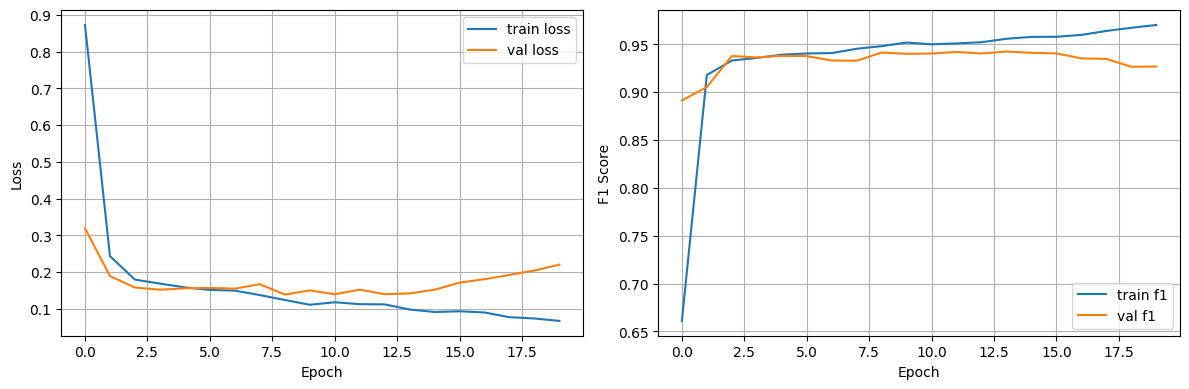

In [ ]:
import matplotlib.pyplot as plt

vocab_size = len(tokenizer.word_index)+1
lstm_model = LSTMModel(vocab_size, num_classes=num_classes)

w = train_model(lstm_model, "LSTM")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(w['train_losses'], label='train loss')
axes[0].plot(w['val_losses'], label='val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(w['train_f1_scores'], label='train f1')
axes[1].plot(w['val_f1_scores'], label='val f1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


эпоха 1:
train_loss = 1.059, val_loss = 1.055
train_f1 = 0.60, val_f1 = 0.75
эпоха 2:
train_loss = 0.440, val_loss = 0.980
train_f1 = 0.87, val_f1 = 0.71
эпоха 3:
train_loss = 0.342, val_loss = 0.873
train_f1 = 0.90, val_f1 = 0.73
эпоха 4:
train_loss = 0.305, val_loss = 0.939
train_f1 = 0.91, val_f1 = 0.77
эпоха 5:
train_loss = 0.282, val_loss = 0.931
train_f1 = 0.91, val_f1 = 0.70
эпоха 6:
train_loss = 0.267, val_loss = 0.750
train_f1 = 0.91, val_f1 = 0.76
эпоха 7:
train_loss = 0.259, val_loss = 0.635
train_f1 = 0.91, val_f1 = 0.86
эпоха 8:
train_loss = 0.257, val_loss = 1.250
train_f1 = 0.91, val_f1 = 0.52
эпоха 9:
train_loss = 0.244, val_loss = 0.810
train_f1 = 0.91, val_f1 = 0.80
эпоха 10:
train_loss = 0.239, val_loss = 0.840
train_f1 = 0.92, val_f1 = 0.79
эпоха 11:
train_loss = 0.232, val_loss = 0.779
train_f1 = 0.92, val_f1 = 0.78
эпоха 12:
train_loss = 0.194, val_loss = 0.946
train_f1 = 0.93, val_f1 = 0.72
эпоха 13:
train_loss = 0.182, val_loss = 0.894
train_f1 = 0.93, val_f1 = 

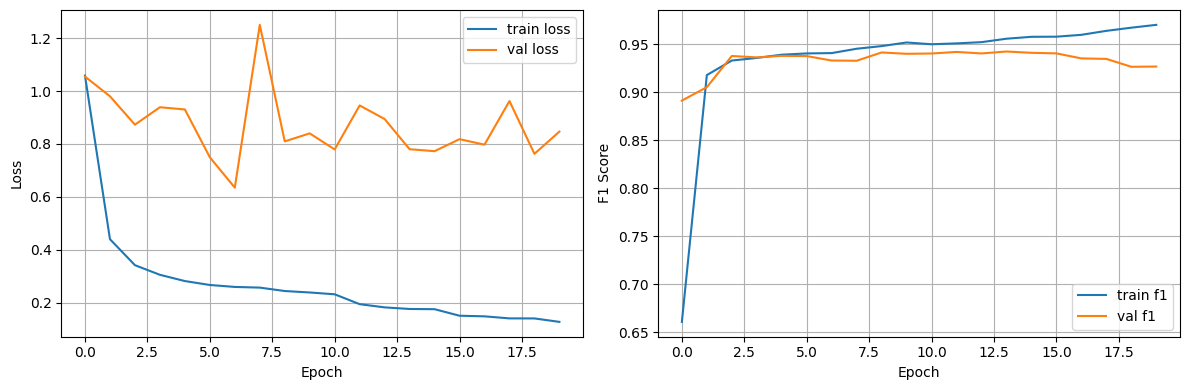

In [ ]:
transformer_model=TransformerModel(vocab_size)

t = train_model(transformer_model, "transformer")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(t['train_losses'], label='train loss')
axes[0].plot(t['val_losses'], label='val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(w['train_f1_scores'], label='train f1')
axes[1].plot(w['val_f1_scores'], label='val f1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

def test_model(model, model_name):
  model.load_state_dict(torch.load(f'best_{model_name}.pth'))
  model=model.to(device)
  model.eval()

  test_preds=[]
  test_lab=[]
  with torch.no_grad():
    for X_batch, y_batch in test_loader:
      X_batch, y_batch= X_batch.to(device), y_batch.to(device)
      y_pred=torch.max(model(X_batch),1)[1]
      test_preds.extend(y_pred.cpu().numpy())
      test_lab.extend(y_batch.cpu().numpy())
  test_f1=f1_score(test_lab, test_preds, average='macro')
  test_acc=accuracy_score(test_lab, test_preds)

  print(f'test f1 (macro): {test_f1:.2f}')
  print(f'test accuracy: {test_acc:.2f}')

  print(f'\nclassification report:')
  print(classification_report(test_lab, test_preds, target_names=le.classes_))

### Тестирование LSTM
- F1 (macro) = 0.89
- Accuracy = 0.93

Лучше всего предсказываются sadness (F1=0.97), joy (0.95), хуже всего - surprise (0.78).

In [ ]:
lstm_results = test_model(lstm_model, "LSTM")

test f1 (macro): 0.95
test accuracy: 0.95

classification report:
              precision    recall  f1-score   support

       anger       0.95      0.96      0.96       624
        fear       0.94      0.91      0.93       621
         joy       0.98      0.93      0.95       676
        love       0.93      0.98      0.96       613
     sadness       0.99      0.95      0.97       641
    surprise       0.92      0.99      0.95       645

    accuracy                           0.95      3820
   macro avg       0.95      0.95      0.95      3820
weighted avg       0.95      0.95      0.95      3820



### Тестирование Transformer
- F1 (macro) = 0.74
- Accuracy = 0.87

Сильно уступает LSTM, особенно по классу surprise (F1=0.22) и love (0.70). Возможная причина: малый объём данных (16k) и недостаточная глубина трансформера (1 слой).

Вывод: LSTM лучше подходит для этого датасета.

In [ ]:
transformer_results = test_model(transformer_model, "transformer")

test f1 (macro): 0.87
test accuracy: 0.87

classification report:
              precision    recall  f1-score   support

       anger       0.89      0.94      0.91       624
        fear       0.98      0.61      0.75       621
         joy       0.97      0.83      0.89       676
        love       0.84      0.96      0.90       613
     sadness       0.85      0.91      0.88       641
    surprise       0.77      0.98      0.86       645

    accuracy                           0.87      3820
   macro avg       0.88      0.87      0.87      3820
weighted avg       0.88      0.87      0.87      3820



In [ ]:
import pickle
import json
from google.colab import files

# сохраняем токенизатор
with open('tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f)

# сохраняем LabelEncoder
with open('label_encoder.pickle', 'wb') as f:
    pickle.dump(le, f)

files.download('tokenizer.pickle')
files.download('label_encoder.pickle')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('best_LSTM.pth')
files.download('best_transformer.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>